# 🧩 Components of Time Series Data

When you look at a time series plot, you are actually looking at an aggregate of four distinct components. Understanding these helps you choose the right forecasting model.

We can describe any time series ($y$) as a combination of:
$$y = \text{Trend} + \text{Seasonality} + \text{Cyclic} + \text{Noise}$$

---

### 1. Trend (The "Long-Term" Direction)
**Definition:** The general direction in which the data is moving over a long period. It shows the underlying growth or decline.

* **Characteristics:** It does not have to be linear. It can be exponential (curved) or change direction (e.g., switching from growth to decay).
* **Example:** The population of a country over 50 years (generally increasing), or the sales of DVDs over the last 10 years (decreasing).

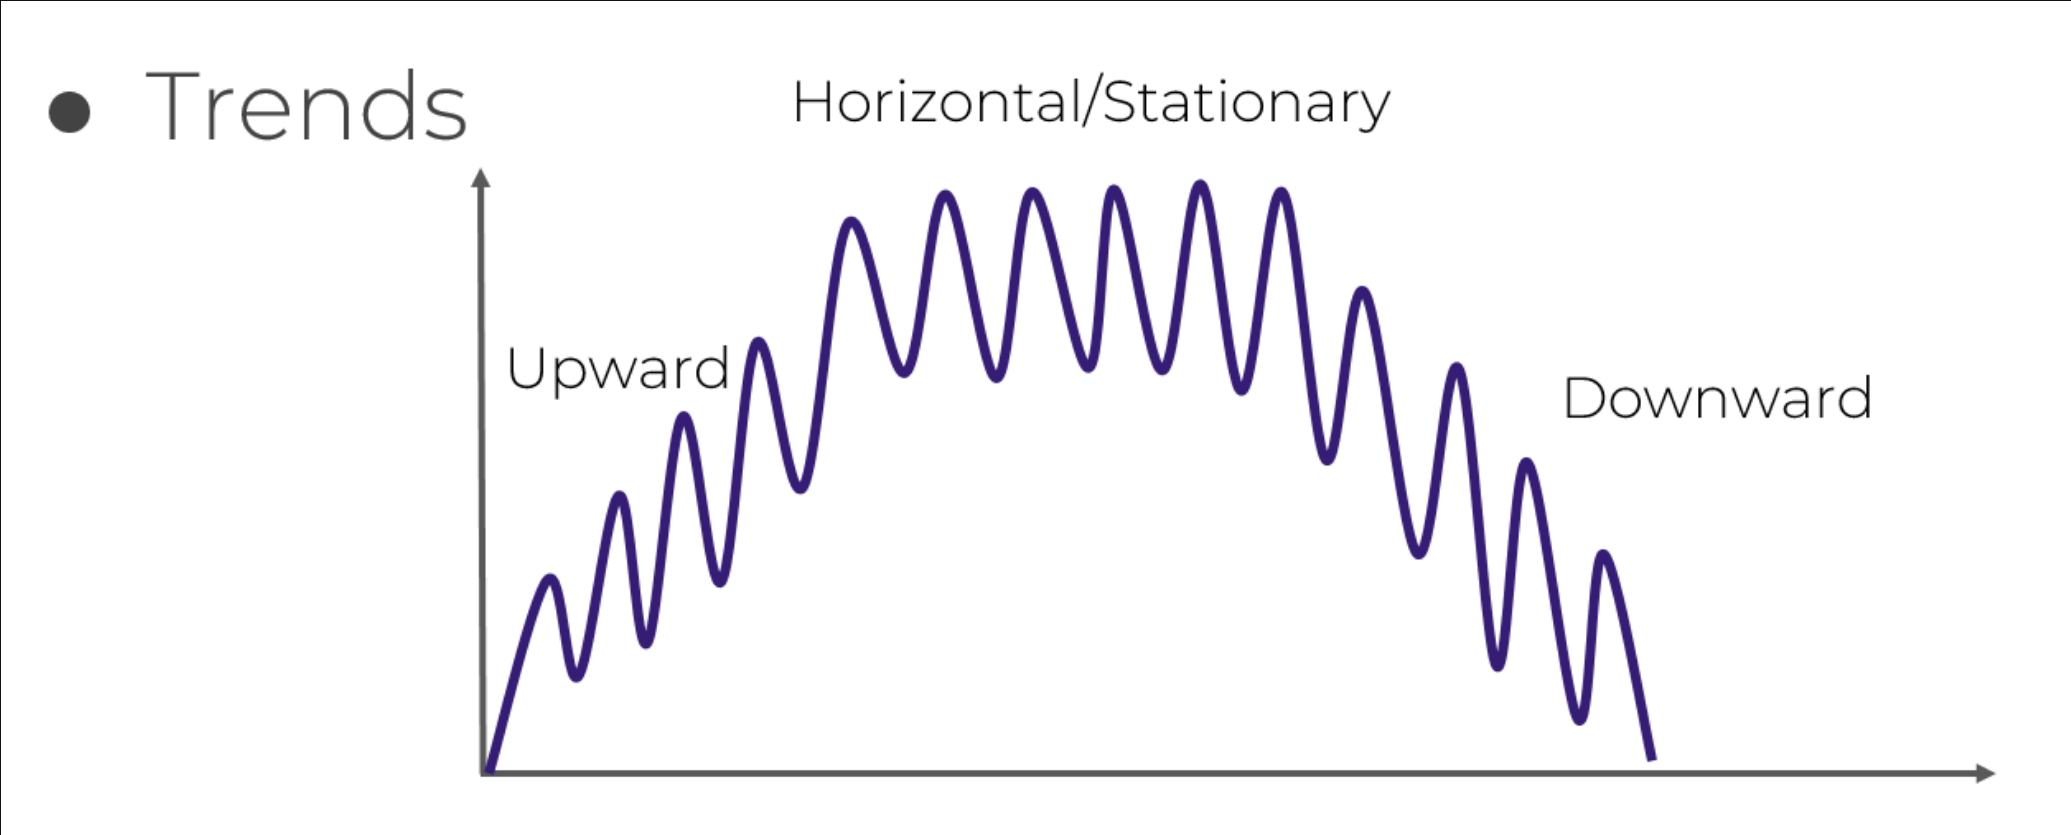


---

## 2. Seasonality (The "Calendar" Pattern)
**Definition:** Patterns that repeat at **fixed, known frequencies**. These are usually driven by the calendar or clock.

* **Characteristics:** The period is always the same (e.g., every 12 months, every 7 days, every 24 hours).
* **Example:**
    * **Retail:** Sales spiking every December (Diwali, Christmas).
    * **Energy:** Electricity usage peaking every afternoon (Daily seasonality).
    * **Travel:** Flight bookings rising every Summer.

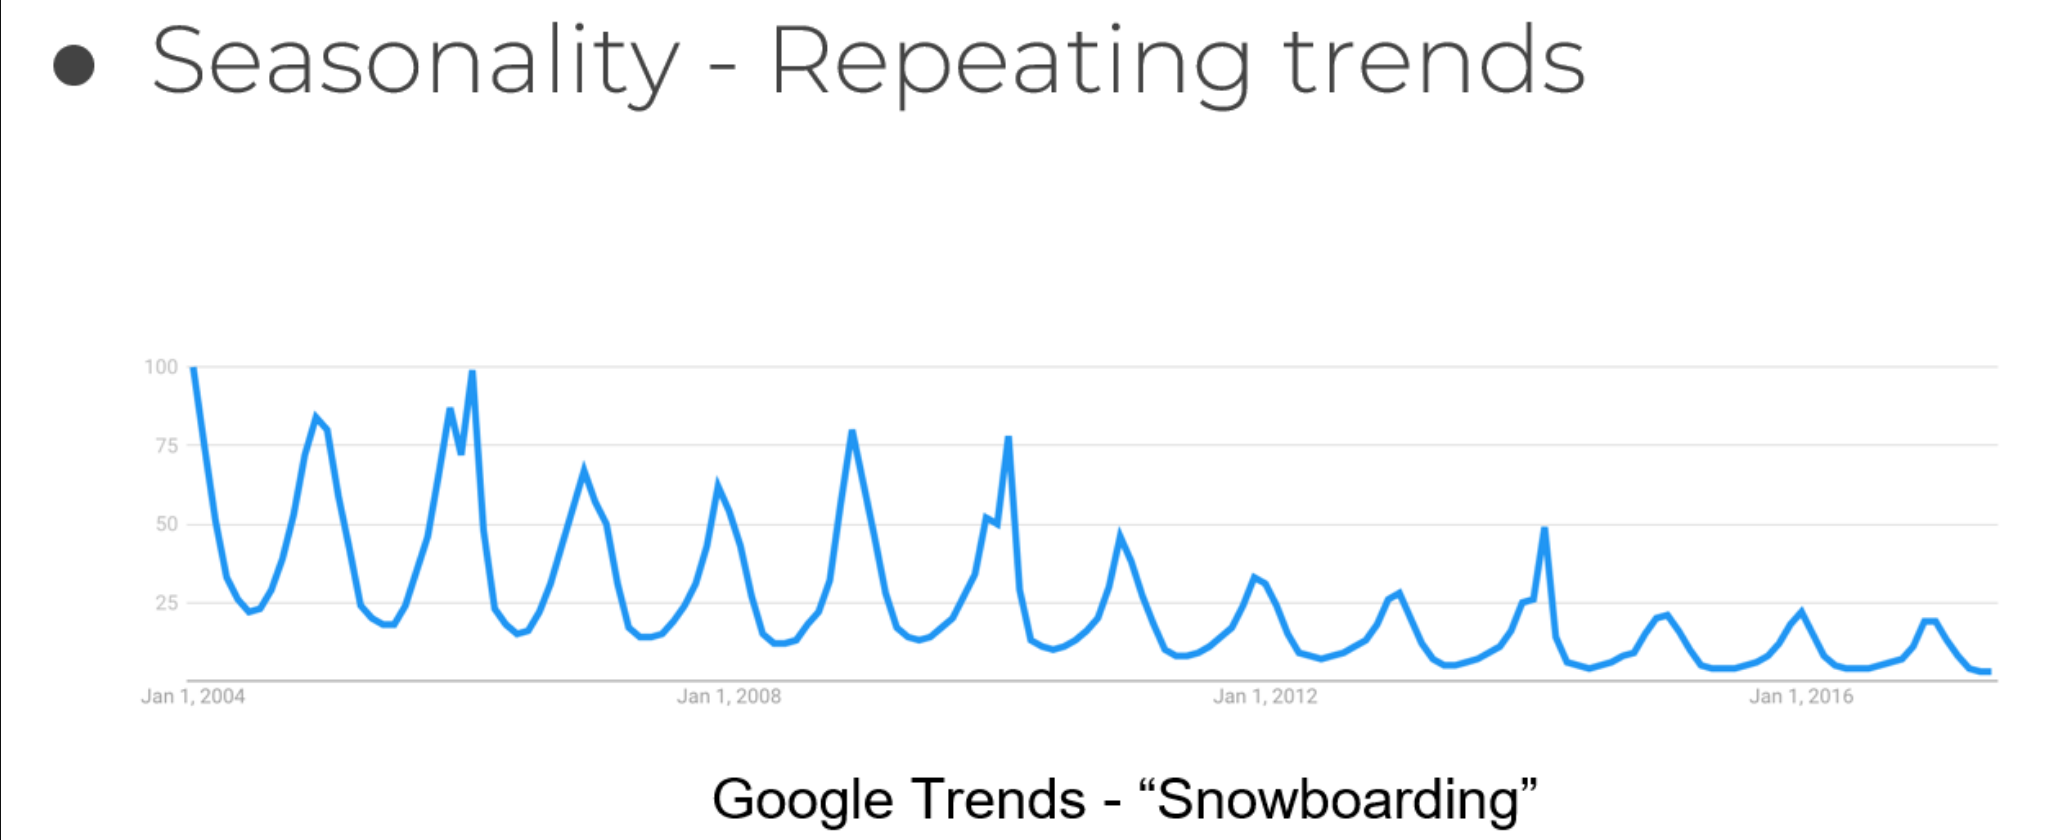


---

## 3. Cyclic (The "Irregular" Wave)
**Definition:** Fluctuations that happen over long periods but—unlike seasonality—are **not** of a fixed frequency.

* **Characteristics:** These rise and fall like a wave, but you don't know exactly how long the wave will last. They are often influenced by macroeconomic factors.
* **Example:** Economic Recessions and Booms (The "Business Cycle"). A recession might last 18 months one time, and 3 years the next time.
* **Key Difference:**
    * *Seasonality* = Predictable timing (e.g., "Every January").
    * *Cyclic* = Unpredictable timing (e.g., "Every few years").

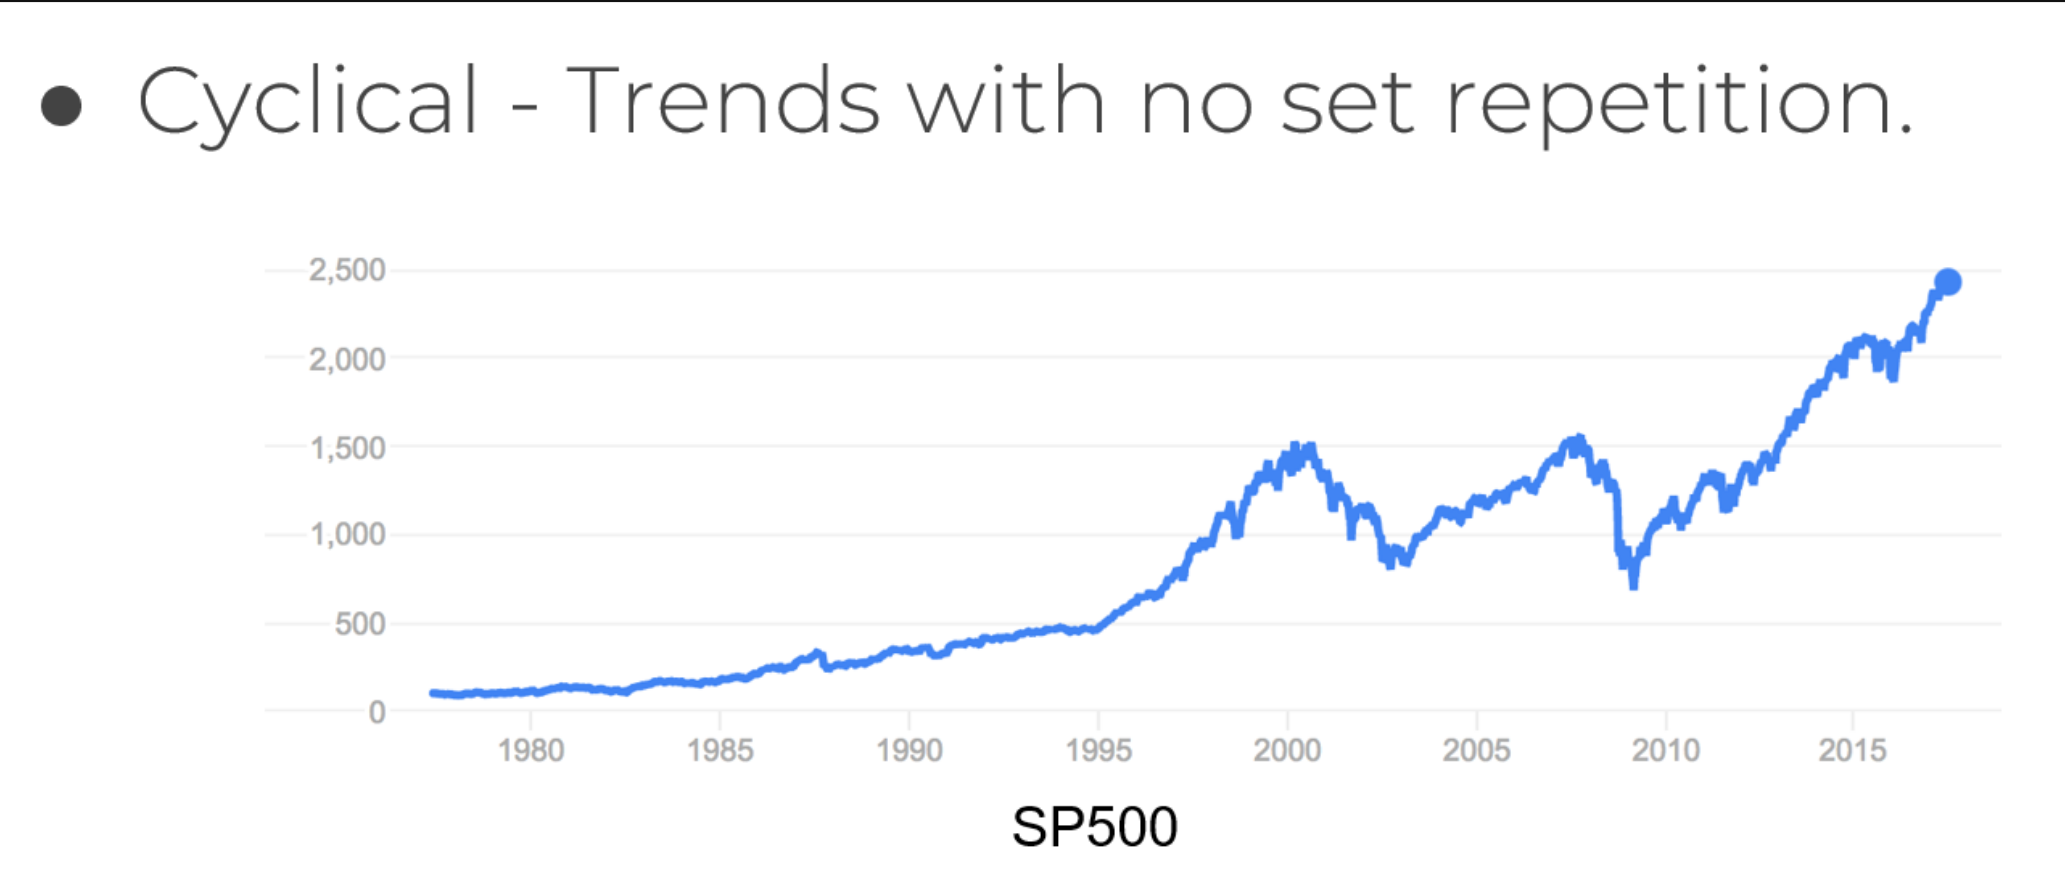

---

## 4. Noise / Residual (The "Randomness")
**Definition:** The random variation in the data that cannot be explained by the trend, seasonality, or cycle.

* **Characteristics:** It looks like static or "white noise." This is the part of the data that is unpredictable.
* **Goal:** A good model captures the Trend and Seasonality so that only Noise is left behind.

---

## 🧮 How they combine: Additive vs. Multiplicative

When we decompose data, we assume these parts combine in one of two ways:

### A. Additive Model
Use this when the **magnitude** of the seasonality stays roughly constant, regardless of the trend.
$$y = \text{Trend} + \text{Seasonality} + \text{Noise}$$
* *Visual Check:* The "waves" in your plot stay the same height even as the graph goes up or down.

### B. Multiplicative Model
Use this when the **magnitude** of the seasonality changes (grows/shrinks) as the trend changes.
$$y = \text{Trend} \times \text{Seasonality} \times \text{Noise}$$
* *Visual Check:* As the graph goes up (trend increases), the "waves" get wider and taller.

# 📉 Hodrick-Prescott (HP) Filter

The **Hodrick-Prescott (HP) Filter** is a mathematical tool used widely in macroeconomics (and financial analysis) to remove short-term fluctuations from a time series.

Its primary goal is to decompose a time series $y_t$ into two components:
1.  **Trend ($\tau_t$):** The long-term growth component.
2.  **Cycle ($c_t$):** The short-term fluctuation around the trend.

$$y_t = \tau_t + c_t$$



## How it works (The Logic)
The HP filter solves a minimization problem. It tries to find a Trend ($\tau$) that satisfies two competing goals at the same time:

1.  **Fit the data:** The trend should be close to the original data points (minimize the Cycle squared).
2.  **Be Smooth:** The trend should not change direction abruptly (minimize the curvature or "roughness" of the trend).

The Balance is controlled by a parameter called **Lambda ($\lambda$)**.

### The Mathematical Objective
$$\min_{\tau} \left( \sum_{t=1}^T (y_t - \tau_t)^2 + \lambda \sum_{t=2}^{T-1} [(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2 \right)$$

* **First Term:** Penalizes the "Cycle" (deviation from the data).
* **Second Term:** Penalizes the change in the Trend's growth rate.
* **$\lambda$ (Lambda):** The "Smoothing Parameter".

## 🔑 The Lambda ($\lambda$) Parameter
This is the most important setting you must choose. It dictates how "stiff" the trend line is.

* **Small $\lambda$:** The trend is flexible and hugs the original data closely (Trend $\approx$ Data).
* **Large $\lambda$:** The trend is very stiff and approaches a straight line.

**Standard Values (Conventions):**
Economists (specifically Ravn and Uhlig) have established standard values based on the frequency of the data:

| Data Frequency | Recommended $\lambda$ Value |
| :--- | :--- |
| **Annual** (Yearly) | $6.25$ |
| **Quarterly** | $1600$ |
| **Monthly** | $129,600$ |

## ⚠️ Limitations
* **End-Point Bias:** The HP Filter performs poorly at the very beginning and very end of the dataset. It tends to overreact to the most recent data points.
* **Static:** It is not a forecasting tool; it is a historical analysis tool.

For these we'll be using a statsmodels built-in macroeconomics dataset:

<pre><strong>US Macroeconomic Data for 1959Q1 - 2009Q3</strong>
Number of Observations - 203
Number of Variables - 14
Variable name definitions:
    year      - 1959q1 - 2009q3
    quarter   - 1-4
    realgdp   - Real gross domestic product (Bil. of chained 2005 US$,
                seasonally adjusted annual rate)
    realcons  - Real personal consumption expenditures (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realinv   - Real gross private domestic investment (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realgovt  - Real federal consumption expenditures & gross investment
                (Bil. of chained 2005 US$, seasonally adjusted annual rate)
    realdpi   - Real private disposable income (Bil. of chained 2005
                US$, seasonally adjusted annual rate)
    cpi       - End of the quarter consumer price index for all urban
                consumers: all items (1982-84 = 100, seasonally adjusted).
    m1        - End of the quarter M1 nominal money stock (Seasonally
                adjusted)
    tbilrate  - Quarterly monthly average of the monthly 3-month
                treasury bill: secondary market rate
    unemp     - Seasonally adjusted unemployment rate (%)
    pop       - End of the quarter total population: all ages incl. armed
                forces over seas
    infl      - Inflation rate (ln(cpi_{t}/cpi_{t-1}) * 400)
    realint   - Real interest rate (tbilrate - infl)</pre>
   

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('macrodata.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


<Axes: >

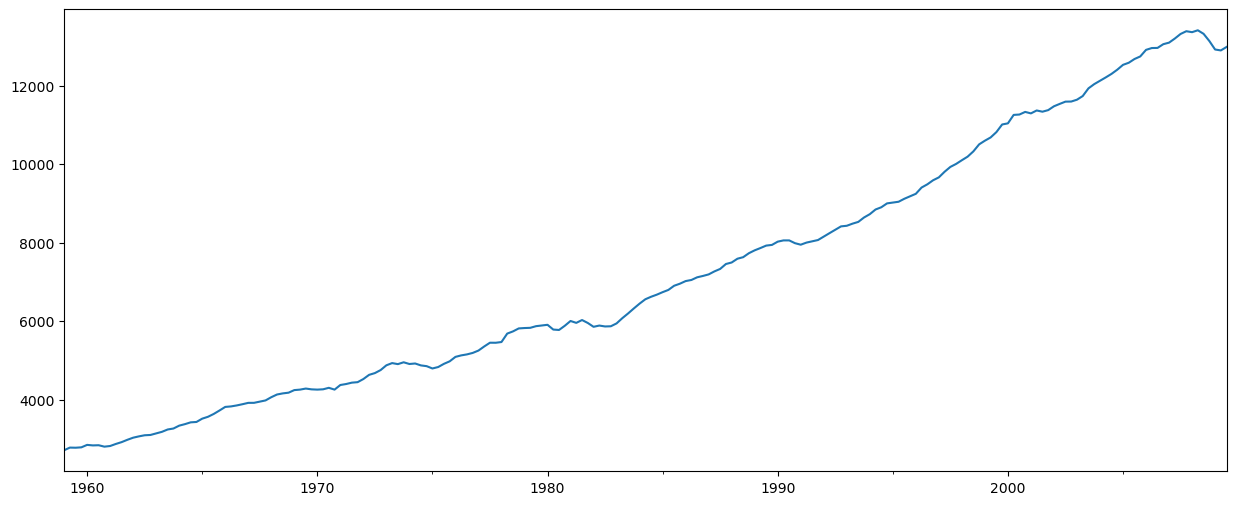

In [4]:
df['realgdp'].plot(kind= 'line', figsize= (15,6))

In [5]:
from statsmodels.tsa.filters.hp_filter import hpfilter

In [6]:
cycle_gdp, trend_gdp = hpfilter(df['realgdp'], lamb= 1600) #lamb= 1600 because we have quarterly data.

C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [7]:
cycle_gdp

1959-03-31     39.511915
1959-06-30     80.088532
1959-09-30     48.875455
1959-12-31     30.591933
1960-03-31     64.882667
                 ...    
2008-09-30    102.018455
2008-12-31   -107.269472
2009-03-31   -349.047706
2009-06-30   -397.557073
2009-09-30   -333.115243
Name: realgdp_cycle, Length: 203, dtype: float64

In [8]:
trend_gdp

1959-03-31     2670.837085
1959-06-30     2698.712468
1959-09-30     2726.612545
1959-12-31     2754.612067
1960-03-31     2782.816333
                  ...     
2008-09-30    13222.581545
2008-12-31    13249.189472
2009-03-31    13274.457706
2009-06-30    13299.061073
2009-09-30    13323.456243
Name: realgdp_trend, Length: 203, dtype: float64

In [9]:
df["GDP_Trend"] = trend_gdp
df["GDP_Cycle"] = cycle_gdp

In [10]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,GDP_Trend,GDP_Cycle
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,2670.837085,39.511915
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,2698.712468,80.088532
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,2726.612545,48.875455
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,2754.612067,30.591933
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,2782.816333,64.882667


<Axes: >

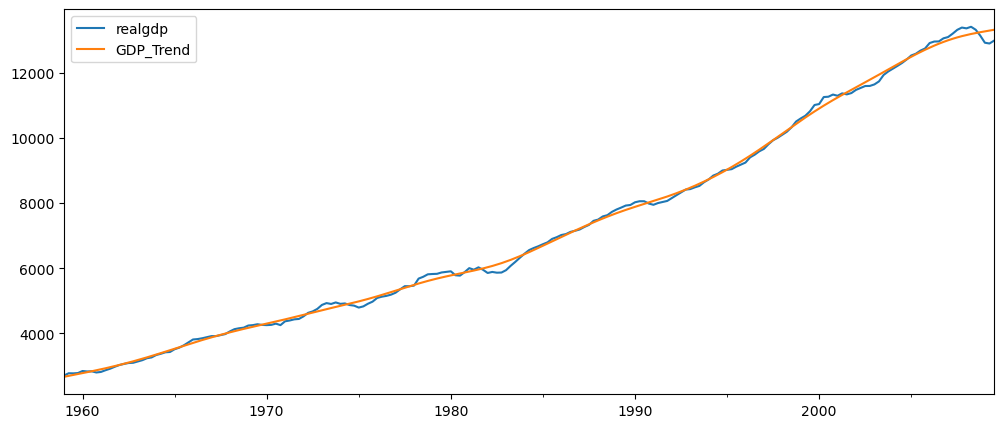

In [11]:
df[['realgdp', 'GDP_Trend']].plot(kind= 'line', figsize= (12,5))

<Axes: >

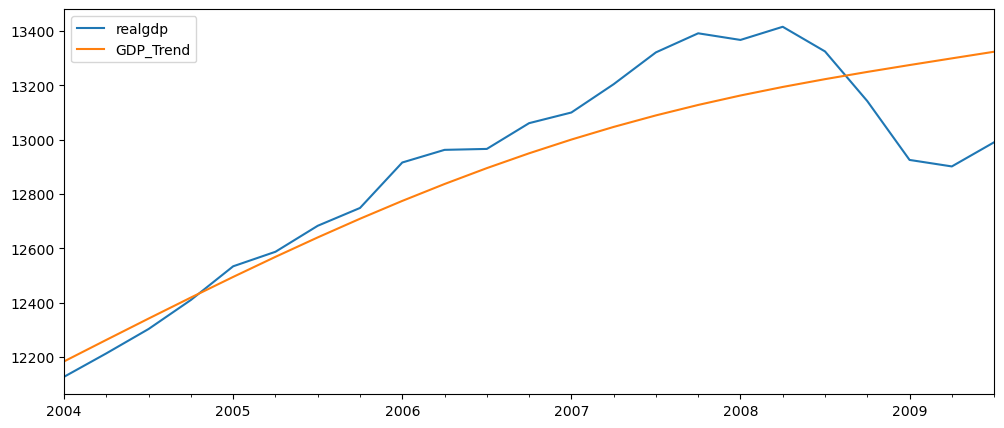

In [16]:
#Zooming in on the Graph above:
df[['realgdp', 'GDP_Trend']]['2004-01-01' : ].plot(kind= 'line', figsize= (12,5))

<Axes: >

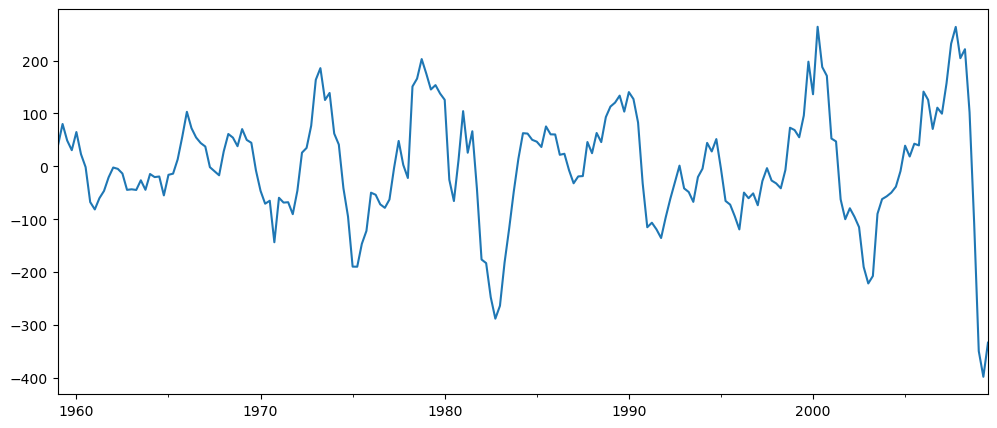

In [17]:
df['GDP_Cycle'].plot(kind= 'line', figsize= (12,5))